In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
sns.set_theme(font_scale=2,palette='colorblind')

path = '/Users/mayageva/Downloads/seeds_dataset.txt'
df = pd.read_csv(path,sep="	")
column_names = ['area','perimeter','compactness','length','width','asymmetry','groove_length','variety']
df.columns = column_names
#for variety: 1 = Kama, 2 = Rosa and 3 = Canadian

# Basic Description
This dataset contains the area, perimter, compactness, length, width, measure of asymmetry, length of the groove on the seed, and variety(which is like the species) of seed kernels from wheat. Units of measurement are in centimeters, and all of the features contain numerical data, except the variety. The varieties are Kama, Rosa and Canadian, which 70 elements each, totaling in 210 instances in the dataset.

Prediction Task:
The task is to predict the variety of wheat seeds based on the numerical features.

Why regression is appropriate:
Regression can be applied to this data due to the fact that all of the features in the data are numerical (except variety which is the target), which is ideal for regression because we calulate relationships between variables. The variety, which is what we will be predicting, is in the data, making it supervised. 

In [30]:
#Fit a linear model on all numerical features with 75% training data
X = df['area'].values[:,np.newaxis]
y = df['variety']
df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(X,y)

In [32]:
#Test it on 25% held out test data and measure the fit with two metrics and one plot
regr = linear_model.LinearRegression()
regr.fit(df_X_train,df_y_train)
df_y_pred = regr.predict(df_X_test)

In [34]:
regr.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'n_features_in_': 1,
 'coef_': array([-0.08975105]),
 'rank_': 1,
 'singular_': array([36.95640268]),
 'intercept_': 3.373568411396395}

In [53]:
i = 1
df_y_pred[i] = regr.coef_*features[i]+ regr.intercept_

NameError: name 'features' is not defined

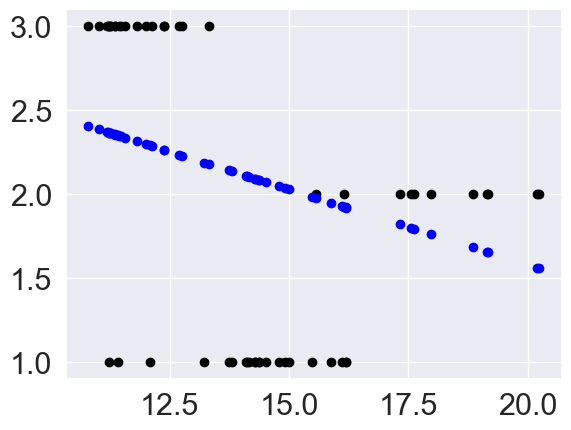

In [70]:
plt.scatter(df_X_test, df_y_test,color = 'black')
plt.scatter(df_X_test, df_y_pred, color='blue')

Inspect the model to answer: What to the coefficients tell you? What to the residuals tell you?

Coefficients:
It seems that some of the  coefficients are negative and some are positive, so as we can see on the graph, some seeds have a positive correlation with their correct variety and some negative.
Resiudals: there are no outliers

In [86]:
#Repeat the split, train, and test steps 5 times.
scores = []
for i in range(5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)    
    X_train = X_train.reshape(-1, 1) 
    X_test = X_test.reshape(-1, 1)
    regr = linear_model.LinearRegression()
    regr.fit(df_X_train,df_y_train)
    df_y_pred = regr.predict(X_test)
    scores.append(regr.score(X_test, y_test))

In [90]:
scores

[0.15553315826075176,
 0.08727641903422012,
 0.1411260034483044,
 0.14788772259091199,
 0.10203658598353016]

Is the performance consistent enough you trust it?
nterpret the model and its performance in terms of the application. Some questions you might want to answer in order to do this include:

do you think this model is good enough to use for real?
No, the scores I got were very low

is this a model you would trust?
Because of the inconsistency is low, I would not trust this model

do you think that a more complex model should be used?
Yes, I believe so.

do you think that maybe this task cannot be done with machine learning?
I think this task can be done with machine learning, just with a different model or some alterations to the data set

I saw the preformance of this model work very well in class on the sample data set we used, but the preformance was not amazing with my seed dataset. This shows inconsistencies and would make me question the model/dataset being used if i wanted to use regression again.